# 04 · Live Camera Detection 🎥

Opens your **webcam** and draws YOLO26 boxes on the live video feed in real time.

> **Run this LOCALLY** (on your own PC with a webcam). It will **not** work on Google
> Colab — Colab has no camera or display, so the video window can't open.
>
> Needs a **GUI build of OpenCV**. If you get
> `cv2.imshow ... The function is not implemented`, your OpenCV is the *headless*
> build — run the fix cell just below, then restart the kernel.

In [ ]:
# Only if you hit the "function is not implemented" error (headless OpenCV).
# Run once, then Kernel -> Restart, then continue:
# %pip uninstall -y opencv-python opencv-python-headless
# %pip install opencv-python

## 1 · Load your model

In [12]:
import os, glob, time
import cv2
from ultralytics import YOLO

# locate repo root (works whether the kernel starts in notebooks/ or the repo root)
cwd = os.getcwd()
ROOT = os.path.abspath(os.path.join(cwd, "..")) if os.path.basename(cwd).lower() == "notebooks" else cwd
MODELS_DIR = os.path.join(ROOT, "models")

# ---- CONFIG ----
SOURCE = 1        # webcam index (0 = default camera). Or a video path like "clip.mp4".
CONF   = 0.35     # confidence threshold
IMGSZ  = 640      # lower (e.g. 416) = faster, less accurate

def default_weights():
    for name in ("model.pt", "best_v2.pt", "best_v1.pt"):
        p = os.path.join(MODELS_DIR, name)
        if os.path.exists(p):
            return p
    found = sorted(glob.glob(os.path.join(MODELS_DIR, "*.pt")))
    if found:
        return found[0]
    print("No trained model in models/ - using pretrained yolo26s.pt (generic COCO objects, not food).")
    return "yolo26s.pt"

WEIGHTS = default_weights()
print("Loading:", WEIGHTS)
model = YOLO(WEIGHTS)
print("Classes:", list(model.names.values()))

Loading: C:\Users\Barho\Desktop\General Assembly\Projects\Bahrain Food Detector\models\model.pt
Classes: ['Balaleet', 'Fried Fish', 'Halwa', 'Harees', 'Kebab', 'Luqaimat', 'Machboos', 'Mattai', 'Nakhi', 'Samboosa']


Working camera indices: [0, 1]


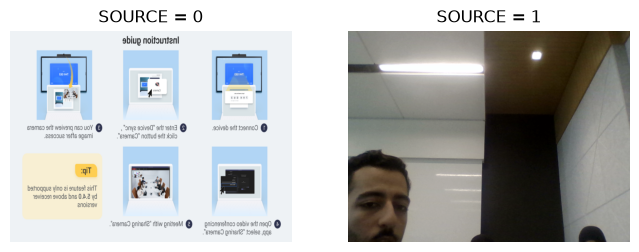

In [13]:
import matplotlib.pyplot as plt
shots = []
for i in range(6):
    cap = cv2.VideoCapture(i, cv2.CAP_DSHOW)
    if cap.isOpened():
        ok, frame = cap.read()
        if ok:
            shots.append((i, frame))
    cap.release()
print("Working camera indices:", [i for i, _ in shots])
if shots:
    fig, axes = plt.subplots(1, len(shots), figsize=(4 * len(shots), 4))
    axes = [axes] if len(shots) == 1 else list(axes)
    for ax, (i, frame) in zip(axes, shots):
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax.set_title(f"SOURCE = {i}"); ax.axis("off")
    plt.show()
else:
    print("No cameras returned a frame - check permissions / close apps using the camera.")

## 2 · Go live
Run the cell below — a window pops up with your camera + detections.
Press **`q`** or **`Esc`** (with the video window focused) to stop.

In [14]:
# open a camera (integer index) or a video file (path).
# CAP_DSHOW makes webcams open fast & reliably on Windows.
cap = cv2.VideoCapture(SOURCE, cv2.CAP_DSHOW) if isinstance(SOURCE, int) else cv2.VideoCapture(SOURCE)
if not cap.isOpened():
    raise RuntimeError(f"Couldn't open source {SOURCE!r}. Try SOURCE=1, or close other apps using the camera.")

print("Camera open - press 'q' or Esc in the video window to stop.")
prev = time.time()
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print("No frame received - stopping.")
            break

        results = model.predict(frame, conf=CONF, imgsz=IMGSZ, verbose=False)
        annotated = results[0].plot()  # frame with boxes + labels

        now = time.time(); fps = 1.0 / max(now - prev, 1e-6); prev = now
        cv2.putText(annotated, f"{fps:4.1f} FPS   |   q = quit", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        cv2.imshow("Bahraini Food Detector - live", annotated)
        if cv2.waitKey(1) & 0xFF in (ord("q"), 27):  # q or Esc
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    for _ in range(4):
        cv2.waitKey(1)   # nudge the window to actually close
print("Stopped.")

Camera open - press 'q' or Esc in the video window to stop.
Stopped.


## Tips
- **Different camera?** set `SOURCE = 1` (or 2) in the config cell.
- **Run on a video file** instead of the webcam: `SOURCE = "myclip.mp4"`.
- **Laggy on CPU?** lower `IMGSZ` to `416`, or use a smaller model. It's smooth on GPU.
- **No trained model yet?** it falls back to `yolo26s.pt` so you can test the camera now
  (it'll box generic objects like *person*, not Bahraini food, until you train).
- If the window won't close, re-run the cell above (the `finally` block releases the camera),
  or restart the kernel.